# **Modelos**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
  

In [17]:
df1_model = pd.read_csv('../datos/procesados/df1_model.csv', sep=';', encoding='latin-1')


In [18]:
print(df1_model['FRAUDE'].unique())

[1 0]


In [19]:
y = df1_model['FRAUDE'].astype(int)
X = df1_model.drop(columns=['FRAUDE'])

In [20]:
X = pd.get_dummies(X, columns=['SEXO', 'SEGMENTO', 'COD_PAIS'], drop_first=False)

Separar los datos

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)   

In [22]:
y_train.shape, y_test.shape

((2368,), (592,))

Entrenar los modelos

1. **LogisticRegression**

In [23]:
rl = LogisticRegression(max_iter=1000)  

In [24]:
rl.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
predictions = rl.predict_proba(X_test)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, predictions))

ROC AUC Score: 0.6235641009890042


In [26]:
rl = LogisticRegression(max_iter=1000, class_weight='balanced')
rl.fit(X_train, y_train)
y_proba = rl.predict_proba(X_test)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, y_proba))

ROC AUC: 0.6682689354382947


Insight 1

*Regresión Logística*

* No fue capaz de distinguir bien las clases

* AUC cercano a 0.5 indica que el modelo es casi aleatorio

* El desbalance de clases lo afectó severamente

* Incluso con class_weight='balanced' no mejoró significativamente

Conclusión: descartado como modelo final

2. **RandomForestClassifier**

In [27]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') 
rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)[:, 1] 
print("ROC AUC RF:", roc_auc_score(y_test, y_proba_rf)) 


ROC AUC RF: 0.9620523373671601


In [28]:
y_pred_rf = rf.predict(X_test)
print("Recall RF:", recall_score(y_test, y_pred_rf))

Recall RF: 0.7397260273972602


In [29]:
print("Precision RF:", precision_score(y_test, y_pred_rf))

Precision RF: 0.9230769230769231


In [30]:
print("F1 Score RF:", f1_score(y_test, y_pred_rf))

F1 Score RF: 0.8212927756653993


Insight 2

*RandomForestClassifier*

* Muy buena precision (0.923): cuando alerta, casi siempre acierta

* Recall bajo (0.740): deja escapar el 26% de los fraudes reales

* Es un modelo conservador y muy selectivo

Conclusión: útil si el equipo de revisión es limitado, pero no ideal para fraude

3. **XGBClassifier**

In [32]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=20
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
print("ROC AUC XGB:", roc_auc_score(y_test, y_proba_xgb))

y_pred_xgb = (y_proba_xgb >= 0.4).astype(int)
print("Recall XGB:", recall_score(y_test, y_pred_xgb))
print("Precision XGB:", precision_score(y_test, y_pred_xgb))
print("F1 XGB:", f1_score(y_test, y_pred_xgb))

c:\Users\Fabian\miniconda3\envs\Fraude\lib\site-packages\xgboost\callback.py:385: UserWarning: [11:40:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


ROC AUC XGB: 0.9468640579888199
Recall XGB: 0.8904109589041096
Precision XGB: 0.7831325301204819
F1 XGB: 0.8333333333333334


Insight 3

*XGBoost (umbral 0.4)*

* Mejor recall (0.890): detecta el 89% de los fraudes reales

* Precision aceptable (0.783): genera más falsas alarmas que RF pero razonable

* Mejor F1 general (0.833)

Conclusión: mejor modelo para detección de fraude

**Matriz de confusión**

<Axes: >

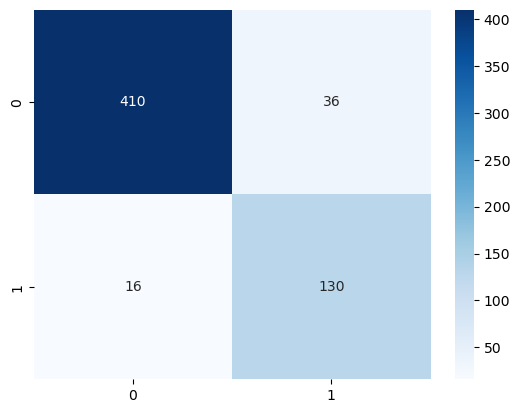

In [33]:
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

Insight 4

* El modelo tiene un excelente desempeño general

* Las falsas alarmas (36) son manejables para un equipo de revisión

* Los fraudes no detectados (16) son pocos, lo que indica que el umbral 0.4 es una buena elección para este caso

In [34]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       446
           1       0.78      0.89      0.83       146

    accuracy                           0.91       592
   macro avg       0.87      0.90      0.89       592
weighted avg       0.92      0.91      0.91       592



Definamos otros umbrales para evaluar el modelo

In [35]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

metrics = []
for threshold in thresholds:
    y_pred_threshold = (y_proba_xgb >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    metrics.append({
        'threshold': threshold,
        'confusion_matrix': cm,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })
    print(f"Threshold: {threshold}")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}\n")  

Threshold: 0.3
Confusion Matrix:
[[394  52]
 [ 12 134]]
Precision: 0.7204301075268817
Recall: 0.9178082191780822
F1 Score: 0.8072289156626506

Threshold: 0.4
Confusion Matrix:
[[410  36]
 [ 16 130]]
Precision: 0.7831325301204819
Recall: 0.8904109589041096
F1 Score: 0.8333333333333334

Threshold: 0.5
Confusion Matrix:
[[418  28]
 [ 20 126]]
Precision: 0.8181818181818182
Recall: 0.863013698630137
F1 Score: 0.84

Threshold: 0.6
Confusion Matrix:
[[427  19]
 [ 28 118]]
Precision: 0.8613138686131386
Recall: 0.8082191780821918
F1 Score: 0.833922261484099

Threshold: 0.7
Confusion Matrix:
[[430  16]
 [ 32 114]]
Precision: 0.8769230769230769
Recall: 0.7808219178082192
F1 Score: 0.8260869565217391

Threshold: 0.8
Confusion Matrix:
[[435  11]
 [ 48  98]]
Precision: 0.8990825688073395
Recall: 0.6712328767123288
F1 Score: 0.7686274509803922



Insight 5

Umbral 0.3 → Máxima detección de fraude

* Deja escapar solo 12 fraudes reales
* Pero genera 52 falsas alarmas
* Útil si el negocio no puede permitirse perder ningún fraude


Umbral 0.4 → Buen balance, orientado a detección

* Deja escapar 16 fraudes
* Genera 36 falsas alarmas
* Mejor F1 considerando el contexto de fraude

Umbral 0.5 → Punto de equilibrio general

* Mejor F1 matemático (0.840)
* 20 fraudes no detectados
* 28 falsas alarmas

Umbral 0.6 → Empieza a ser conservador

* Ya deja escapar 28 fraudes
* Pero reduce falsas alarmas a 19

Umbral 0.7 → Conservador

* Deja escapar 32 fraudes (22% del total)
* Muy pocas falsas alarmas (16)

Umbral 0.8 → Muy conservador, no recomendado para fraude

* Deja escapar 48 fraudes (33% del total)
* Recall cae a 0.671, lo que significa que 1 de cada 3 fraudes no se detecta

Conclusión práctica:

* Si el negocio prioriza detectar fraude: usar 0.3 o 0.4
* Si el negocio prioriza reducir falsas alarmas: usar 0.6 o 0.7
* Si se busca equilibrio matemático: usar 0.5
* Nunca usar 0.8 en fraude bancario porque pierde demasiados fraudes reales

Recomendación final: umbral 0.4, porque detecta el 89% de los fraudes con un número manejable de falsas alarmas (36).

